## **K-Means**

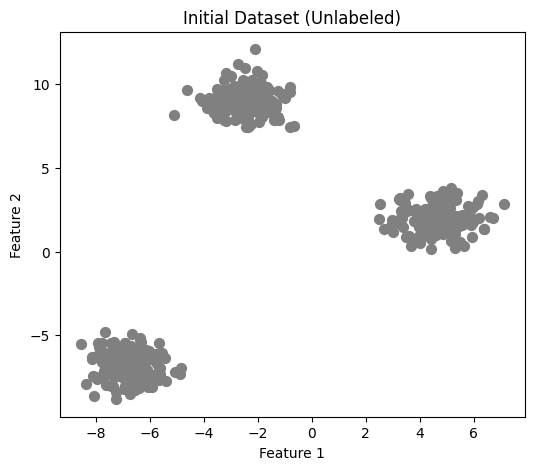

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

# -------------------------------------------------
# 1. Generate synthetic 2D dataset
# -------------------------------------------------
X, y_true = make_blobs(n_samples=500, centers=3, cluster_std=0.8, random_state=42)

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], s=50, c='gray')
plt.title("Initial Dataset (Unlabeled)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [21]:
# -------------------------------------------------
# 2. K-Means from scratch (using only NumPy)
# -------------------------------------------------

K = 3
np.random.seed(33)
centroids = X[np.random.choice(X.shape[0], K, replace=False)] ### If replace=True, same point can be chosen multiple times.

max_iters = 20
cost_history = []

for iteration in range(max_iters):
    # Step 1: Assign each point to nearest centroid
    distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)  # (n_samples, K)
    cluster_idx = np.argmin(distances, axis=1)
    
    # Step 2: Compute cost (sum of squared distances)
    cost = np.sum((X - centroids[cluster_idx]) ** 2)
    cost_history.append(cost)
    print(f"Iteration {iteration+1}: Cost = {cost:.4f}")
    
    # Step 3: Update centroids
    new_centroids = np.array([X[cluster_idx == k].mean(axis=0) for k in range(K)])
    
    # Stop if centroids do not move
    if np.allclose(centroids, new_centroids):
        print("Converged.")
        break
    centroids = new_centroids

Iteration 1: Cost = 12661.6608
Iteration 2: Cost = 8990.7282
Iteration 3: Cost = 8985.9729
Iteration 4: Cost = 8983.3268
Iteration 5: Cost = 8982.5349
Iteration 6: Cost = 8981.6726
Iteration 7: Cost = 8980.5326
Iteration 8: Cost = 8980.0269
Iteration 9: Cost = 8979.8689
Iteration 10: Cost = 8979.8526
Converged.


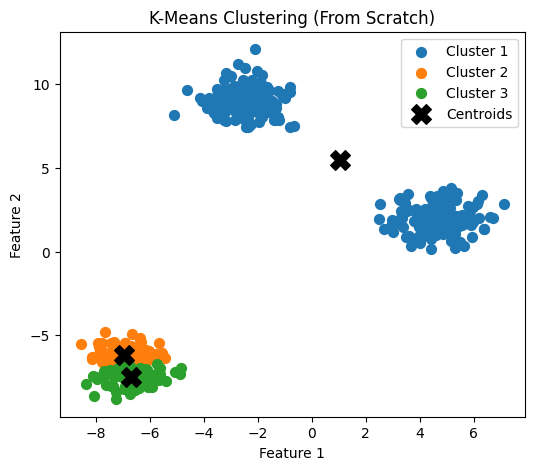

In [22]:
# -------------------------------------------------
# 3. Visualize clustering result
# -------------------------------------------------
plt.figure(figsize=(6, 5))
for k in range(K):
    cluster_points = X[cluster_idx == k]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], s=50, label=f"Cluster {k+1}")
plt.scatter(centroids[:, 0], centroids[:, 1], s=200, c='black', marker='X', label='Centroids')
plt.title("K-Means Clustering (From Scratch)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

Iteration 1: Cost = 1113.2713


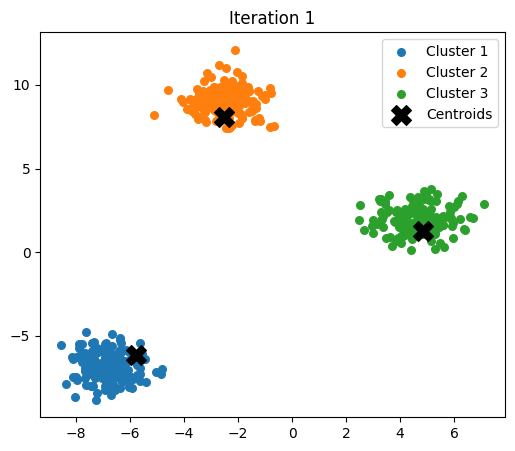

Iteration 2: Cost = 611.6156


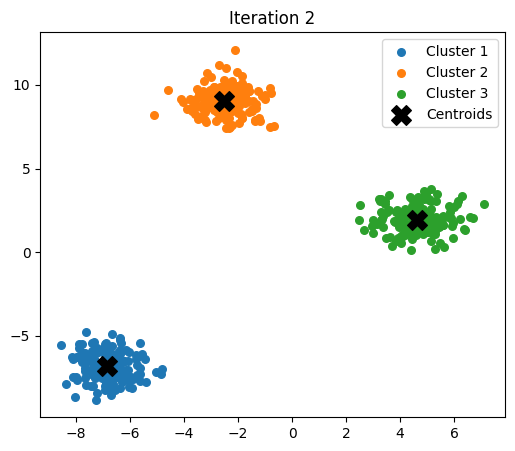

Converged.


In [25]:
K = 3
np.random.seed() ## 5 is one of the best seeds
centroids = X[np.random.choice(X.shape[0], K, replace=False)]

max_iters = 20
cost_history = []

for iteration in range(max_iters):
    # Step 1: Assign each point to nearest centroid
    distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
    cluster_idx = np.argmin(distances, axis=1)
    
    # Step 2: Compute cost
    cost = np.sum((X - centroids[cluster_idx]) ** 2)
    cost_history.append(cost)
    print(f"Iteration {iteration+1}: Cost = {cost:.4f}")
    
    # Step 3: Plot clustering
    plt.figure(figsize=(6, 5))
    for k in range(K):
        plt.scatter(X[cluster_idx == k, 0], X[cluster_idx == k, 1], s=30, label=f'Cluster {k+1}')
    plt.scatter(centroids[:, 0], centroids[:, 1], c='black', s=200, marker='X', label='Centroids')
    plt.title(f'Iteration {iteration+1}')
    plt.legend()
    plt.show()
    
    # Step 4: Update centroids
    new_centroids = np.array([X[cluster_idx == k].mean(axis=0) for k in range(K)])
    
    # Stop if centroids do not move
    if np.allclose(centroids, new_centroids):
        print("Converged.")
        break
    centroids = new_centroids

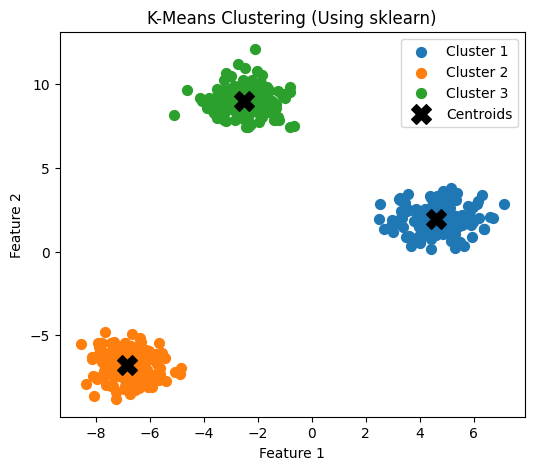

In [26]:
# -------------------------------------------------
# Compare with sklearn’s KMeans
# -------------------------------------------------
sk_kmeans = KMeans(n_clusters=3, random_state=42)
sk_labels = sk_kmeans.fit_predict(X)
sk_centroids = sk_kmeans.cluster_centers_

plt.figure(figsize=(6, 5))
for k in range(K):
    cluster_points = X[sk_labels == k]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], s=50, label=f"Cluster {k+1}")
plt.scatter(sk_centroids[:, 0], sk_centroids[:, 1], s=200, c='black', marker='X', label='Centroids')
plt.title("K-Means Clustering (Using sklearn)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

## **K-Means++**

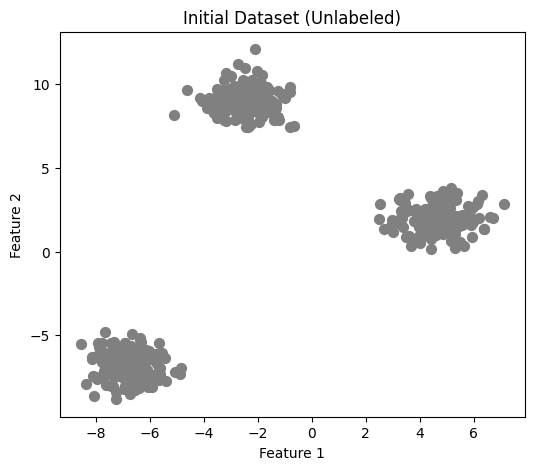

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

# -------------------------------------------------
# 1. Generate synthetic 2D dataset
# -------------------------------------------------
X, y_true = make_blobs(n_samples=500, centers=3, cluster_std=0.8, random_state=42)

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], s=50, c='gray')
plt.title("Initial Dataset (Unlabeled)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

Initial centroids (K-Means++):
 [[-2.30315731  8.9547294 ]
 [ 3.42772599  3.0666691 ]
 [-5.72204488 -6.72286577]]
Iteration 1: Cost = 1277.3331
Iteration 2: Cost = 611.6156
Converged.


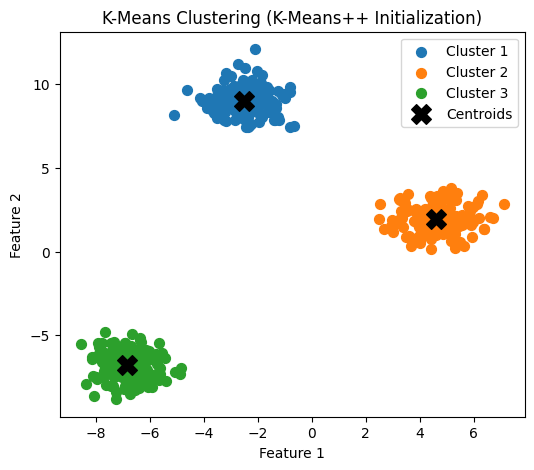

In [31]:
# -------------------------------------------------
# 1. K-Means++ initialization function
# -------------------------------------------------
def kmeans_plus_plus_init(X, K, random_state=42):
    np.random.seed(random_state)
    n_samples = X.shape[0]
    centroids = []

    # Step 1: randomly choose first centroid
    first_idx = np.random.randint(0, n_samples)
    centroids.append(X[first_idx])

    # Step 2: choose next centroids
    for _ in range(1, K):
        # Compute distance to nearest chosen centroid for each point
        distances = np.array([min(np.linalg.norm(x - c)**2 for c in centroids) for x in X])
        # Compute probability distribution proportional to squared distances
        probs = distances / distances.sum()
        # Choose next centroid index based on probability
        next_idx = np.random.choice(n_samples, p=probs)
        centroids.append(X[next_idx])

    return np.array(centroids)

# -------------------------------------------------
# 2. K-Means algorithm using K-Means++ initialization
# -------------------------------------------------
K = 3
centroids = kmeans_plus_plus_init(X, K, random_state=0)
print("Initial centroids (K-Means++):\n", centroids)

max_iters = 20
cost_history = []

for iteration in range(max_iters):
    # Step 1: Assign to nearest centroid
    distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
    cluster_idx = np.argmin(distances, axis=1)

    # Step 2: Compute cost (sum of squared distances)
    cost = np.sum((X - centroids[cluster_idx]) ** 2)
    cost_history.append(cost)
    print(f"Iteration {iteration+1}: Cost = {cost:.4f}")

    # Step 3: Update centroids
    new_centroids = np.array([X[cluster_idx == k].mean(axis=0) for k in range(K)])

    # Step 4: Check convergence
    if np.allclose(centroids, new_centroids):
        print("Converged.")
        break

    centroids = new_centroids


# -------------------------------------------------
# 3. Plot final clusters
# -------------------------------------------------
plt.figure(figsize=(6, 5))
for k in range(K):
    cluster_points = X[cluster_idx == k]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], s=50, label=f"Cluster {k+1}")
plt.scatter(centroids[:, 0], centroids[:, 1], s=200, c='black', marker='X', label='Centroids')
plt.title("K-Means Clustering (K-Means++ Initialization)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()


## **Choosing Right K**

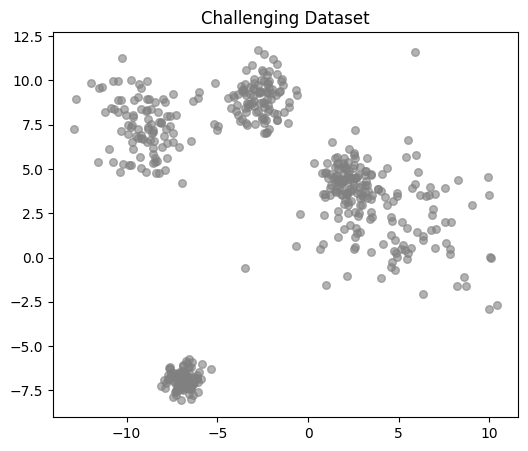

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_circles, make_blobs

# -------------------------------------------------
# 1. Generate a more challenging dataset
# -------------------------------------------------
np.random.seed(42)
# You can switch between datasets to experiment:
# X, _ = make_moons(n_samples=500, noise=0.1, random_state=42)
# X, _ = make_circles(n_samples=500, factor=0.5, noise=0.05, random_state=42)
X, _ = make_blobs(n_samples=500, centers=5, cluster_std=[1.0, 2.5, 0.5, 1.5, 0.8], random_state=42)

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c='gray', s=30, alpha=0.6)
plt.title("Challenging Dataset")
plt.show()

In [33]:
# -------------------------------------------------
# 2. K-Means++ initialization function
# -------------------------------------------------
def kmeans_plus_plus_init(X, K, random_state=42):
    np.random.seed(random_state)
    n_samples = X.shape[0]

    # Choose first centroid randomly
    centroids = [X[np.random.choice(n_samples)]]

    for _ in range(1, K):
        # Compute distance from nearest centroid
        distances = np.min(np.linalg.norm(X[:, np.newaxis] - np.array(centroids), axis=2)**2, axis=1)
        probabilities = distances / np.sum(distances)
        cumulative_probs = np.cumsum(probabilities)
        r = np.random.rand()

        # Choose next centroid
        for j, p in enumerate(cumulative_probs):
            if r < p:
                centroids.append(X[j])
                break
    return np.array(centroids)


# -------------------------------------------------
# 3. K-Means++ algorithm from scratch
# -------------------------------------------------
def kmeans_plus_plus(X, K, max_iters=30, random_state=42, visualize=False):
    centroids = kmeans_plus_plus_init(X, K, random_state)
    cost_history = []

    for iteration in range(max_iters):
        # Step 1: Assign each point to nearest centroid
        distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
        cluster_idx = np.argmin(distances, axis=1)

        # Step 2: Compute cost (sum of squared distances)
        cost = np.sum((X - centroids[cluster_idx])**2)
        cost_history.append(cost)

        # Step 3: Visualization
        if visualize:
            plt.figure(figsize=(6, 5))
            for k in range(K):
                plt.scatter(X[cluster_idx == k, 0], X[cluster_idx == k, 1], s=30, label=f'Cluster {k+1}')
            plt.scatter(centroids[:, 0], centroids[:, 1], c='black', s=200, marker='X', label='Centroids')
            plt.title(f'Iteration {iteration+1}, Cost = {cost:.2f}')
            plt.legend()
            plt.show()

        # Step 4: Update centroids
        new_centroids = np.array([X[cluster_idx == k].mean(axis=0) for k in range(K)])

        # Stop if converged
        if np.allclose(centroids, new_centroids):
            print(f"Converged at iteration {iteration+1}, Cost = {cost:.2f}")
            break
        centroids = new_centroids

    return centroids, cluster_idx, cost_history[-1]

Converged at iteration 2, Cost = 31369.00
Converged at iteration 3, Cost = 15962.09
Converged at iteration 3, Cost = 4726.76
Converged at iteration 5, Cost = 3735.78
Converged at iteration 5, Cost = 1584.62
Converged at iteration 6, Cost = 1373.63
Converged at iteration 10, Cost = 1212.56
Converged at iteration 17, Cost = 1136.06
Converged at iteration 17, Cost = 981.48


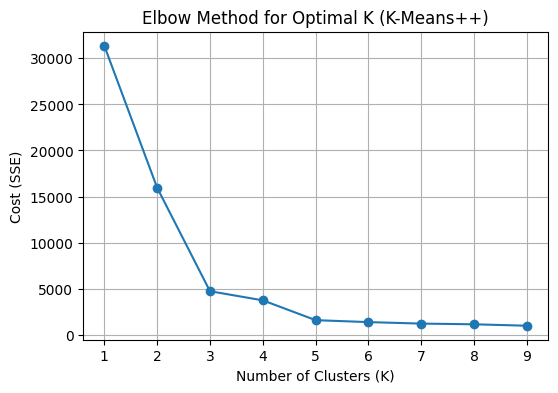

In [34]:
# -------------------------------------------------
# 4. Elbow Method to find the optimal K
# -------------------------------------------------
costs = []
K_values = range(1, 10)

for K in K_values:
    _, _, cost = kmeans_plus_plus(X, K, max_iters=20, random_state=42)
    costs.append(cost)

plt.figure(figsize=(6, 4))
plt.plot(K_values, costs, marker='o')
plt.title("Elbow Method for Optimal K (K-Means++)")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Cost (SSE)")
plt.grid(True)
plt.show()


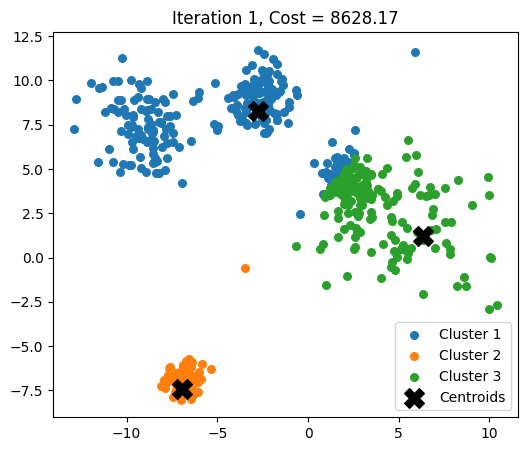

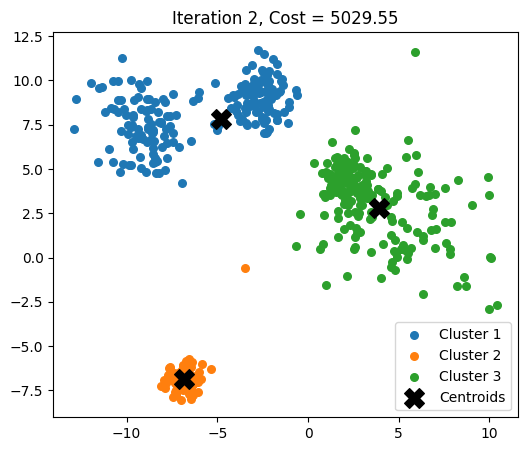

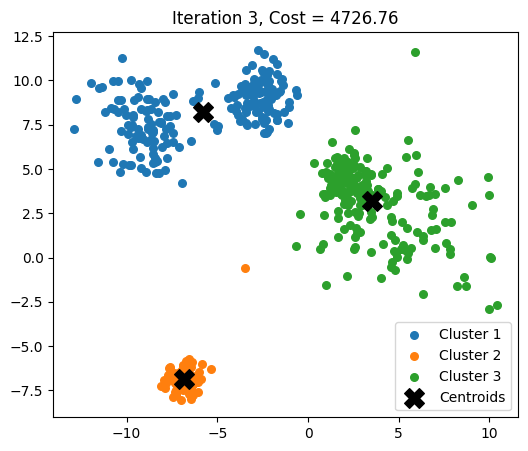

Converged at iteration 3, Cost = 4726.76


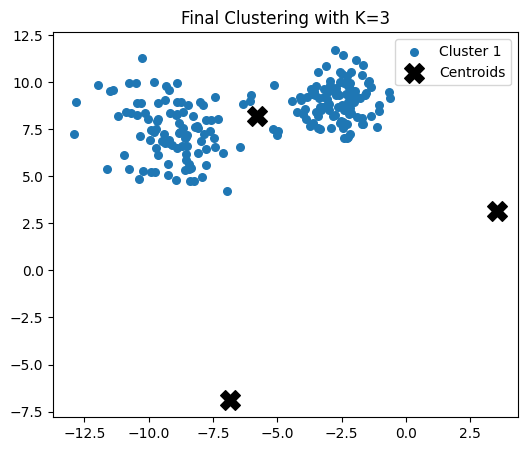

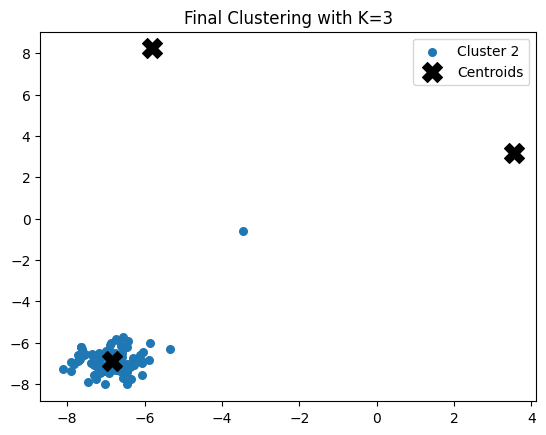

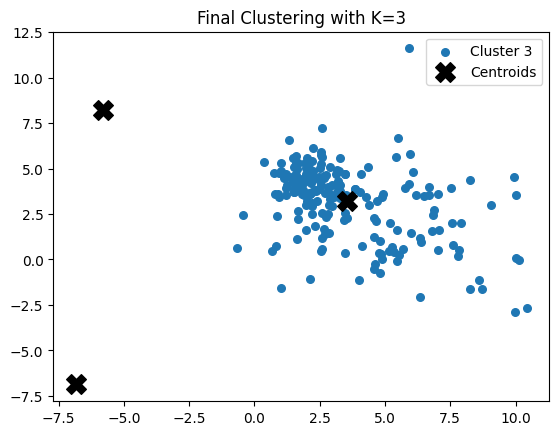

In [36]:
# -------------------------------------------------
# 5. Run K-Means++ for the chosen K (say, K=5 from elbow)
# -------------------------------------------------
best_K = 3  # or you can inspect the elbow plot and choose manually
centroids, labels, _ = kmeans_plus_plus(X, best_K, visualize=True)

plt.figure(figsize=(6, 5))
for k in range(best_K):
    plt.scatter(X[labels == k, 0], X[labels == k, 1], s=30, label=f'Cluster {k+1}')
    plt.scatter(centroids[:, 0], centroids[:, 1], c='black', s=200, marker='X', label='Centroids')
    plt.title(f"Final Clustering with K={best_K}")
    plt.legend()
    plt.show()